In [1]:
!pip install opendatasets


In [4]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/ruchikakumbhar/calories-burnt-prediction")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bilalilyasjhandir
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ruchikakumbhar/calories-burnt-prediction


100%|██████████| 236k/236k [00:00<00:00, 271MB/s]

In [6]:
import pandas as pd
df = pd.read_csv("/content/calories-burnt-prediction/calories.csv")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [7]:
!pip install xgboost lightgbm

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv("/content/calories-burnt-prediction/calories.csv")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [11]:
print("shape:", df.shape)

print("\nmissing values:\n", df.isnull().sum())

print("\ndata types:\n", df.dtypes)

shape: (15000, 9)

missing values:
 User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

data types:
 User_ID         int64
Gender         object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object


In [13]:
df = df.drop("User_ID", axis=1)

In [14]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [15]:
X = df.drop("Calories", axis=1)
y = df["Calories"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("training size:", X_train.shape)
print("testing size:", X_test.shape)

training size: (12000, 7)
testing size: (3000, 7)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [19]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [20]:
xgbr = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgbr.fit(X_train, y_train)
xgb_pred = xgbr.predict(X_test)

In [21]:
lgbm = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm.fit(X_train, y_train)
lgb_pred = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.095417


In [24]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Results:")
    print("rmse:", rmse)
    print("mae:", mae)
    print("r2 score:", r2)
    print("\n")
    return rmse, mae, r2

lr_results = evaluate_model(y_test, lr_pred, "linear regression")
rf_results = evaluate_model(y_test, rf_pred, "random forest")
xgb_results = evaluate_model(y_test, xgb_pred, "xgboost")
lgb_results = evaluate_model(y_test, lgb_pred, "lightgbm")

linear regression Results:
rmse: 11.48894014915288
mae: 8.441513553849703
r2 score: 0.9672937151257295


random forest Results:
rmse: 2.6833820078401063
mae: 1.7173133333333332
r2 score: 0.9982158297720679


xgboost Results:
rmse: 1.7513526850150856
mae: 1.2241583960056306
r2 score: 0.9992399914008103


lightgbm Results:
rmse: 1.8647197696854532
mae: 1.2834486794591151
r2 score: 0.9991384144004999




In [25]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "LightGBM"],
    "RMSE": [lr_results[0], rf_results[0], xgb_results[0], lgb_results[0]],
    "MAE": [lr_results[1], rf_results[1], xgb_results[1], lgb_results[1]],
    "R2 Score": [lr_results[2], rf_results[2], xgb_results[2], lgb_results[2]]
})
results_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,11.488940,8.441514,0.967294
1,Random Forest,2.683382,1.717313,0.998216
2,XGBoost,1.751353,1.224158,0.999240
3,LightGBM,1.864720,1.283449,0.999138


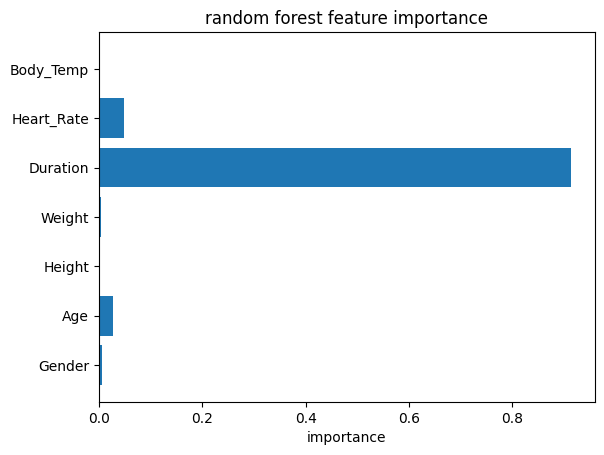

In [26]:
importances = rf.feature_importances_
features = X.columns
plt.figure()
plt.barh(features, importances)
plt.xlabel("importance")
plt.title("random forest feature importance")
plt.show()

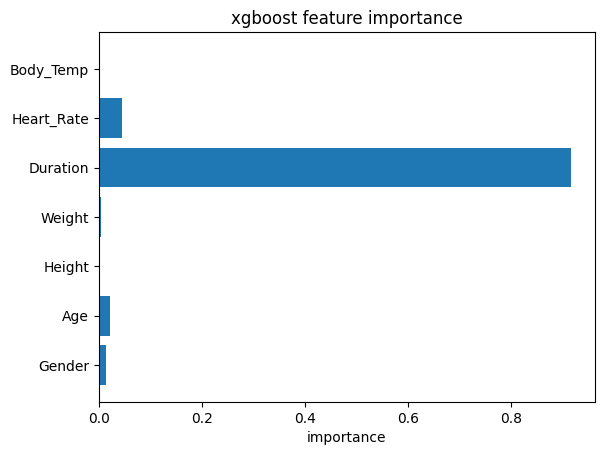

In [30]:
xgb_importances = xgbr.feature_importances_
plt.figure()
plt.barh(X.columns, xgb_importances)
plt.xlabel("importance")
plt.title("xgboost feature importance")
plt.show()

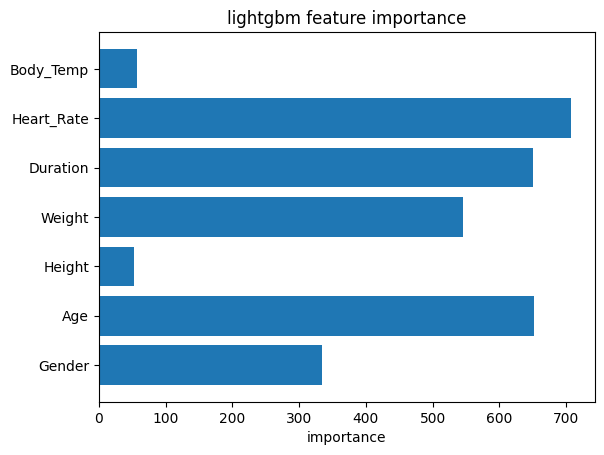

In [31]:
lgb_importances = lgbm.feature_importances_
plt.figure()
plt.barh(X.columns, lgb_importances)
plt.xlabel("importance")
plt.title("lightgbm feature importance")
plt.show()

In [32]:
import joblib
joblib.dump(xgbr, "calorie_model.pkl")

['calorie_model.pkl']

Hyper-Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
rf_model = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("best random forest parameters:", rf_grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
best random forest parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [35]:
rf_tuned_pred = best_rf.predict(X_test)
evaluate_model(y_test, rf_tuned_pred, "tuned random forest")

tuned random forest Results:
rmse: 2.6526313885146826
mae: 1.6912600000000002
r2 score: 0.998256487402074




(np.float64(2.6526313885146826), 1.6912600000000002, 0.998256487402074)

In [36]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1]
}
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print("best xgboost parameters:", xgb_grid.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
best xgboost parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [37]:
xgb_tuned_pred = best_xgb.predict(X_test)
evaluate_model(y_test, xgb_tuned_pred, "tuned xgboost")

tuned xgboost Results:
rmse: 1.583982832948477
mae: 1.139875361988942
r2 score: 0.9993783123758581




(np.float64(1.583982832948477), 1.139875361988942, 0.9993783123758581)

In [38]:
lgb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [-1, 10, 20],
    "num_leaves": [31, 50]
}
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_grid = GridSearchCV(
    estimator=lgb_model,
    param_grid=lgb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
lgb_grid.fit(X_train, y_train)
best_lgb = lgb_grid.best_estimator_
print("best lightgbm parameters:", lgb_grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.095417
best lightgbm parameters: {'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 200, 'num_leaves': 50}


In [39]:
lgb_tuned_pred = best_lgb.predict(X_test)
evaluate_model(y_test, lgb_tuned_pred, "tuned lightgbm")

tuned lightgbm Results:
rmse: 1.552496959771325
mae: 1.0473748699032777
r2 score: 0.9994027821249843




(np.float64(1.552496959771325), 1.0473748699032777, 0.9994027821249843)

In [40]:
def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

In [41]:
rf_tuned_pred = best_rf.predict(X_test)
xgb_tuned_pred = best_xgb.predict(X_test)
lgb_tuned_pred = best_lgb.predict(X_test)

In [42]:
rf_metrics = get_metrics(y_test, rf_tuned_pred)
xgb_metrics = get_metrics(y_test, xgb_tuned_pred)
lgb_metrics = get_metrics(y_test, lgb_tuned_pred)

In [44]:
comparison_full = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "RMSE Before": [rf_results[0], xgb_results[0], lgb_results[0]],
    "RMSE After":  [rf_metrics[0], xgb_metrics[0], lgb_metrics[0]],
    "MAE Before":  [rf_results[1], xgb_results[1], lgb_results[1]],
    "MAE After":   [rf_metrics[1], xgb_metrics[1], lgb_metrics[1]],
    "R2 Before":   [rf_results[2], xgb_results[2], lgb_results[2]],
    "R2 After":    [rf_metrics[2], xgb_metrics[2], lgb_metrics[2]],
})
comparison_full

,Model,RMSE Before,RMSE After,MAE Before,MAE After,R2 Before,R2 After
0,Random Forest,2.683382,2.652631,1.717313,1.691260,0.998216,0.998256
1,XGBoost,1.751353,1.583983,1.224158,1.139875,0.999240,0.999378
2,LightGBM,1.864720,1.552497,1.283449,1.047375,0.999138,0.999403


In [46]:
comparison_full["RMSE Reduction"] = comparison_full["RMSE Before"] - comparison_full["RMSE After"]
comparison_full["MAE Reduction"] = comparison_full["MAE Before"] - comparison_full["MAE After"]
comparison_full["R2 Improvement"] = comparison_full["R2 After"] - comparison_full["R2 Before"]
comparison_full

,Model,RMSE Before,RMSE After,MAE Before,MAE After,R2 Before,R2 After,R2 Improvement,RMSE Reduction,MAE Reduction
0,Random Forest,2.683382,2.652631,1.717313,1.691260,0.998216,0.998256,0.000041,0.030751,0.026053
1,XGBoost,1.751353,1.583983,1.224158,1.139875,0.999240,0.999378,0.000138,0.167370,0.084283
2,LightGBM,1.864720,1.552497,1.283449,1.047375,0.999138,0.999403,0.000264,0.312223,0.236074


In [47]:
import joblib
joblib.dump(best_lgb, "calorie_model_tuned.pkl")

['calorie_model_tuned.pkl']

In [48]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']